# Methylated reads classification with EpigenDnabert2

This tutorial demonstrates:
1. **Predicting on real data using a fine-tuned model from a checkpoint**.
2. **Initializing a model to support all features (cpg_methylation and m6a_methylation)** and making predictions on synthetic data with varying sequence lengths.
---


### Step 0: Set paths to checkpoint and data

You need to specify your checkpoint and data locations

In [ ]:
checkpoint_path = "output/dnabert2_chr19_top3000_global_dmrs_dmrs_cuts/checkpoint-1600/model.safetensors"
data_path = "../Data/Curated/rrms_dmrs_only_mincov40_corrected_imporvement_experiments/chr19_top3000_global_dmrs_original_reads"

### Step 1: Import Libraries

Importing the necessary libraries for working with EpigenDnabert2, managing datasets, and visualizing results.

In [190]:
from syto.modelling.dnabert2 import EpigenDnabert2
from syto.data.dataset import SupervisedDataset, generate_example_data
import os
import torch
import time
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np

### Step 2: Predicting on Real Data Using a Fine-Tuned Model

In this section, we load a pre-trained EpigenDnabert2 model from a checkpoint and use it to make predictions on real test data. The data is stored as a CSV file.


In [ ]:
# import torch
# torch.__version__
# torch.cuda.is_available()

In [ ]:
max_sequence_length = 1000

In [198]:
epigenbert = EpigenDnabert2(
    fine_tuned_model_path=checkpoint_path, max_sequence_length=max_sequence_length
)

In [ ]:
# Load test dataset
test_dataset = SupervisedDataset(
    tokenizer=epigenbert.tokenizer,
    data_path_or_list=os.path.join(data_path, "test"),
    kmer=-1,
    data_interface="pandas",
)

In [ ]:
valid_dataset = SupervisedDataset(
    tokenizer=epigenbert.tokenizer,
    data_path_or_list=os.path.join(data_path, "valid"),
    kmer=-1,
    data_interface="pandas",
)

In [ ]:
rest_dataset = SupervisedDataset(
    tokenizer=epigenbert.tokenizer,
    data_path_or_list=os.path.join(data_path, "rest"),
    kmer=-1,
    data_interface="pandas",
)

In [ ]:
# Make predictions
res_test = epigenbert.predict(test_dataset)

In [ ]:
res_valid = epigenbert.predict(valid_dataset)

In [ ]:
res_rest = epigenbert.predict(rest_dataset)

In [ ]:
import pickle
import os

if not os.path.exists(data_path + "/dnabert2_datasets_prepared/"):
    os.mkdir(data_path + "/dnabert2_datasets_prepared/")
for target_data, name in zip(
    [test_dataset, valid_dataset, rest_dataset], ["test", "valid", "rest"]
):
    with open(
        data_path
        + f"/dnabert2_datasets_prepared/{name}_max_seq_length_{max_sequence_length}_naive_trunctation.pkl",
        "wb",
    ) as f:
        pickle.dump(target_data, f)

In [ ]:
with open(
    f"output/dnabert2_rrms_chr1/checkpoint-10850/predictions_max_seq_length_{max_sequence_length}_naive_trunctation.pkl",
    "wb",
) as f:
    all_predictions = {"test": res_test, "valid": res_valid, "rest": res_rest}
    pickle.dump(all_predictions, f)

In [ ]:
with open(
    f"output/dnabert2_rrms_chr1/checkpoint-10850/predictions_max_seq_length_2000_naive_trunctation.pkl",
    "rb",
) as f:
    all_predictions = pickle.load(f)

In [ ]:
res_test, res_valid, res_rest = (
    all_predictions["test"],
    all_predictions["valid"],
    all_predictions["rest"],
)

In [ ]:
test_data = pd.read_parquet(data_path + "/test.parquet")

In [ ]:
valid_data = pd.read_parquet(data_path + "/valid.parquet")

In [ ]:
rest_data = pd.read_parquet(data_path + "/rest.parquet")

In [ ]:
target = "test"
filtering = False

if target == "valid":
    target_data = valid_data
    target_result = res_valid
elif target == "test":
    target_data = test_data
    target_result = res_test
elif target == "rest":
    target_data = rest_data
    target_result = res_rest


from sklearn.metrics import confusion_matrix, auc, roc_curve
import numpy as np

target_indexes = list(target_data.loc[target_data["read_length"] <= 1000].index)
# Set Matplotlib styling
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "grid.color": "lightgray",
        "grid.linestyle": "-",
    }
)

# Compute confusion matrix
labels_filtered = target_result.label_ids
predictions_filtered = target_result.predictions
if filtering:
    labels_filtered = labels_filtered[target_indexes]
    predictions_filtered = predictions_filtered[target_indexes]

cf_matrix = confusion_matrix(labels_filtered, predictions_filtered > 0.5)

# Create the heatmap using Matplotlib
fig, ax = plt.subplots(1, figsize=(6, 6))
cax = ax.matshow(cf_matrix, cmap="PiYG")
plt.colorbar(cax)

# Annotate the heatmap
for (i, j), val in np.ndenumerate(cf_matrix):
    ax.text(
        j,
        i,
        f"{val}",
        ha="center",
        va="center",
        color="white" if val > cf_matrix.max() / 2 else "black",
    )

# Set axis labels and tick marks
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Ground-truth", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["N", "T"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["N", "T"])

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(labels_filtered, predictions_filtered)
auc_val = auc(fpr, tpr)

# Set title with AUC value
ax.set_title(f"DNABERT2 RRMS Chr1 Test (auc: {auc_val:.3f})", fontsize=14)

# Show plot
plt.tight_layout()
plt.show()

### Step 2.5: Predicting in scaled regime

In [ ]:
# data_path = "../Data/Curated/rrms_dmrs_only_mincov40_corrected/chr19"

In [192]:
test_data = pd.read_parquet(data_path + "/test.parquet")
max_read_length = np.max([len(x) for x in test_data["input_ids"]])

In [193]:
test_data = test_data.loc[
    (test_data["original_file"] == "COLO829BL_5.bam")
    | (test_data["original_file"] == "COLO829_5.bam"),
]

In [ ]:
# test_data = pd.read_parquet(data_path+"/rest.parquet")
max_read_length = np.max([len(x) for x in test_data["input_ids"]])
max_sequence_length = 1000
predictions = []
labels = []
max_sequence_lengths = []
read_names = []
for max_sequence_length in tqdm(reversed(range(1000, max_read_length + 1, 1000))):
    # print(max_sequence_length)
    subset_data = test_data[
        (test_data["sequence_length"] > max_sequence_length - 1000)
        & (test_data["sequence_length"] <= max_sequence_length)
    ]
    if subset_data.shape[0]:
        epigenbert = EpigenDnabert2(
            fine_tuned_model_path=checkpoint_path,
            max_sequence_length=max_sequence_length,
        )
        # Load test dataset
        test_dataset = SupervisedDataset(
            tokenizer=epigenbert.tokenizer,
            data_path_or_list=subset_data,
            kmer=-1,
            data_interface="pandas",
        )

        batch_size = max(
            1,
            int(
                250
                / (max_sequence_length * 1.5 ** (np.sqrt(max_sequence_length / 3500)))
                * 1000
            ),
        )
        # else:
        #     batch_size = 1
        res_test = epigenbert.predict(test_dataset, batch_size)
        predictions.extend(res_test[0])
        labels.extend(res_test[1])
        max_sequence_lengths.extend([max_sequence_length] * subset_data.shape[0])
        read_names.extend(subset_data["read_name"])

In [199]:
from typing import List, Dict
import pandas as pd
import numpy as np


def split_long_reads(df: pd.DataFrame, max_read_length: int) -> pd.DataFrame:
    """
    Split DNA reads longer than max_read_length into smaller chunks.

    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing DNA read data
    max_read_length : int
        Maximum allowed read length for splitting

    Returns:
    --------
    pd.DataFrame
        Transformed dataset with split reads and calculated CpG counts
    """

    def count_cpgs(methylation_string: str) -> int:
        """Count CpG sites (represented by '1' or '2' in methylation_ids)
        0 - unmethylated C, 1 - methylated C, 2 - methylation status unknown"""
        return sum(1 for char in methylation_string if char in ["0", "1"])

    def split_single_read(row: pd.Series) -> List[Dict]:
        """Split a single read into chunks if it exceeds max_read_length"""
        # Extract relevant fields directly from the pandas Series
        read_name = row["read_name"]
        input_ids = row["input_ids"]
        methylation_ids = row["methylation_ids"]
        chromosome = row["chromosome"]
        original_file = row["original_file"]
        label = row["label"]

        # Get the actual sequence length
        sequence_length = len(input_ids)

        # If the read is within the max length, return as is
        if sequence_length <= max_read_length:
            return [
                {
                    "read_name": read_name,
                    "input_ids": input_ids,
                    "methylation_ids": methylation_ids,
                    "chromosome": chromosome,
                    "original_file": original_file,
                    "label": label,
                    "num_cpgs": count_cpgs(methylation_ids),
                }
            ]

        # Split the read into chunks
        chunks = []
        for i in range(0, sequence_length, max_read_length):
            end_idx = min(i + max_read_length, sequence_length)

            # Extract the chunk
            chunk_input_ids = input_ids[i:end_idx]
            chunk_methylation_ids = methylation_ids[i:end_idx]

            chunks.append(
                {
                    "read_name": read_name,
                    "input_ids": chunk_input_ids,
                    "methylation_ids": chunk_methylation_ids,
                    "chromosome": chromosome,
                    "original_file": original_file,
                    "label": label,
                    "num_cpgs": count_cpgs(chunk_methylation_ids),
                }
            )

        return chunks

    # Process all rows
    all_chunks = []
    for _, row in df.iterrows():
        chunks = split_single_read(row)
        all_chunks.extend(chunks)

    # Convert to DataFrame
    result_df = pd.DataFrame(all_chunks)

    return result_df

In [200]:
data_chuncked = split_long_reads(test_data, max_read_length=1000)

In [201]:
epigenbert = EpigenDnabert2(
    fine_tuned_model_path=checkpoint_path, max_sequence_length=1000
)
# Load test dataset
test_dataset = SupervisedDataset(
    tokenizer=epigenbert.tokenizer,
    data_path_or_list=data_chuncked,
    kmer=-1,
    data_interface="pandas",
)
res_test_chunked = epigenbert.predict(test_dataset)

C:\Users\rizdvanetskyi\.cache\huggingface\modules\transformers_modules\zhihan1996\DNABERT-2-117M\d064dece8a8b41d9fb8729fbe3435278786931f1\bert_layers.py:126: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(
X:\KULeuven-Masters\Master Thesis\syto\syto\syto\modelling\dnabert2.py:461: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  return transformers.Trainer(model=self.model,
X:\KULeuven-Masters\Master Thesis\syto\syto\syto\modelling\dnabert2.py:482: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  prediction_trainer = transformers.Trainer(


In [202]:
data_chuncked["predictions_proba"] = res_test_chunked.predictions
data_chuncked["predictions_weighted"] = (
    data_chuncked["predictions_proba"] * data_chuncked["num_cpgs"]
)
data_chunked_agg = data_chuncked.groupby("read_name").agg(
    predictions_weighted=pd.NamedAgg(column="predictions_weighted", aggfunc="sum"),
    # predictions_weighted=pd.NamedAgg(column="predictions_proba", aggfunc="median"),
    num_cpgs=pd.NamedAgg(column="num_cpgs", aggfunc="sum"),
    label=pd.NamedAgg(column="label", aggfunc="min"),
)

data_chunked_agg["num_cpgs"] = [max(x, 1) for x in data_chunked_agg["num_cpgs"]]

data_chunked_agg["predictions_weighted"] = (
    data_chunked_agg["predictions_weighted"] / data_chunked_agg["num_cpgs"]
)
data_chunked_agg["predictions"] = data_chunked_agg["predictions_weighted"] > 0.5
data_chunked_agg = data_chunked_agg.loc[data_chunked_agg["num_cpgs"] > 0,]
labels_chuncked, predictions_chunked, predictions_proba_chunked = (
    data_chunked_agg["label"],
    data_chunked_agg["predictions"],
    data_chunked_agg["predictions_weighted"],
)

In [203]:
predictions_full = pd.DataFrame(np.array([read_names, predictions]).T)

In [204]:
predictions_full.columns = ["read_name", "prediction_full"]

In [206]:
predictions_full["read_name"] = predictions_full["read_name"].astype(str)
predictions_full["prediction_full"] = predictions_full["prediction_full"].astype(float)
data_chunked_agg_reset = data_chunked_agg.reset_index()
data_chunked_agg_reset["read_name"] = data_chunked_agg_reset["read_name"].astype(str)

result = predictions_full.merge(
    data_chunked_agg_reset[["read_name", "predictions_weighted", "label"]],
    on="read_name",
    how="left",  # or "inner", "outer", "right" depending on your needs
)

In [207]:
result["combined_score"] = (
    result["prediction_full"] + result["predictions_weighted"]
) / 2

In [214]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


def cohen_d(group1, group2):
    """
    Computes Cohen's d to measure effect size between two distributions.
    Implemented based on ConceptsOfBiometrics.pdf, slide 77.

    Parameters:
    - group1, group2: Arrays of numerical values.

    Returns:
    - Cohen's d value (effect size).
    """
    mean1, mean2 = np.mean(group1), np.mean(group2)
    n1, n2 = len(group1), len(group2)
    std1, std2 = np.std(group1, ddof=1), np.std(group2, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    return abs((mean1 - mean2)) / pooled_std


def plot_filled_kde(values, groups, alpha=0.4, ax=None, bw_adjust=0.4, name="Default"):
    """
    Plots overlapping KDE (Kernel Density Estimation) curves with filled areas for two groups (0 and 1).
    Also computes Cohen's d to measure effect size.

    Parameters:
    - values: A list or numpy array of numerical values.
    - groups: A list or numpy array of group labels (0 or 1).
    - alpha: Transparency level for the filled area under KDE curves (default is 0.4).
    - ax: Matplotlib axis to plot on (optional).
    """
    # Convert to numpy arrays
    values = np.array(values)
    groups = np.array(groups)

    # Ensure groups contain only 0s and 1s
    unique_groups = np.unique(groups)
    if len(unique_groups) > 2 or set(unique_groups) - {0, 1}:
        raise ValueError("Groups should contain only 0 and 1.")

    # Separate values by group
    values_0 = values[groups == 0]  # Impostor scores
    values_1 = values[groups == 1]  # Genuine scores

    # Compute Uniquness and permanence
    uniqueness = np.abs(np.mean(values_0) - np.mean(values_1))

    n1, n2 = len(values_0), len(values_1)
    std1, std2 = np.std(values_0, ddof=1), np.std(values_1, ddof=1)  # Unbiased std
    pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
    d_value = cohen_d(values_0, values_1)
    # permanence = pooled_std

    # If no axis is provided, create one
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))

    # KDE plots with filled area
    sns.kdeplot(
        values_0,
        color="blue",
        fill=True,
        alpha=alpha,
        label="Normal Distribution",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )
    sns.kdeplot(
        values_1,
        color="red",
        fill=True,
        alpha=alpha,
        label="Tumour Distribution",
        linewidth=2,
        ax=ax,
        bw_adjust=bw_adjust,
    )

    # Labels and legend
    ax.set_xlabel("Model Score")
    ax.set_ylabel("Density")
    ax.set_title(
        f"{name} Cohen's d: {d_value:.2f}, \n Means Difference: {uniqueness:.3f}, \n Pooled StDev: {pooled_std:.3f}"
    )
    ax.legend()
    ax.set_xlim(0, 1)
    ax.grid(True, linestyle="--", alpha=0.6)

    # If ax is None, show the plot
    if ax is None:
        plt.show()

In [208]:
import matplotlib

font = {"family": "Verdana", "weight": "regular", "size": 28}

matplotlib.rc("font", **font)

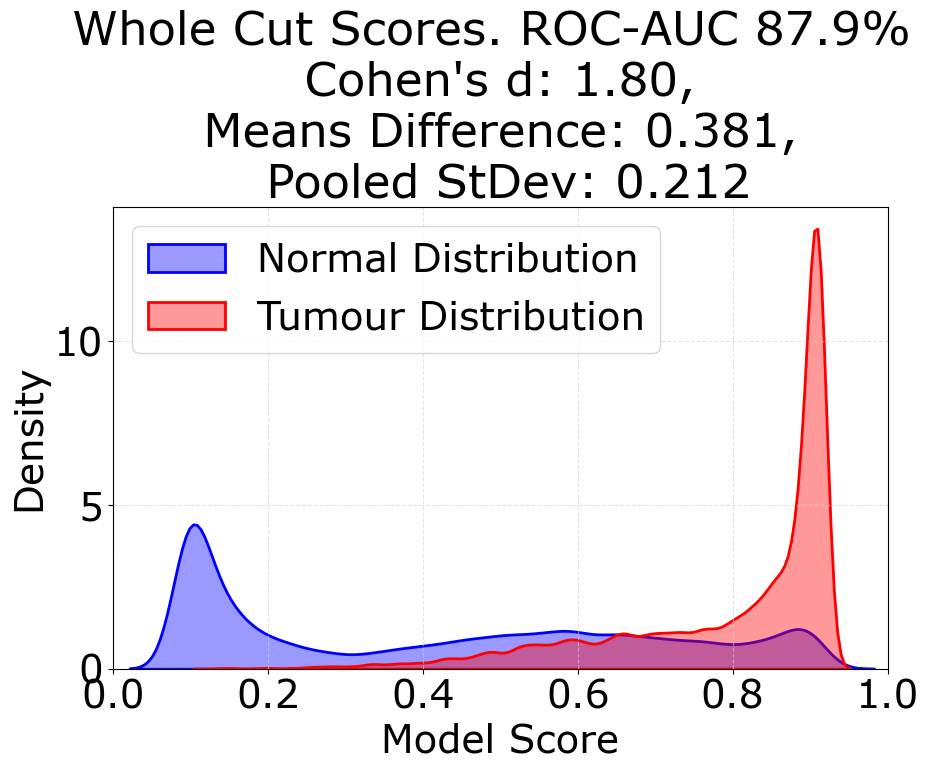

In [215]:
plot_filled_kde(predictions, labels, name="Whole Cut Scores. ROC-AUC 87.9% \n")

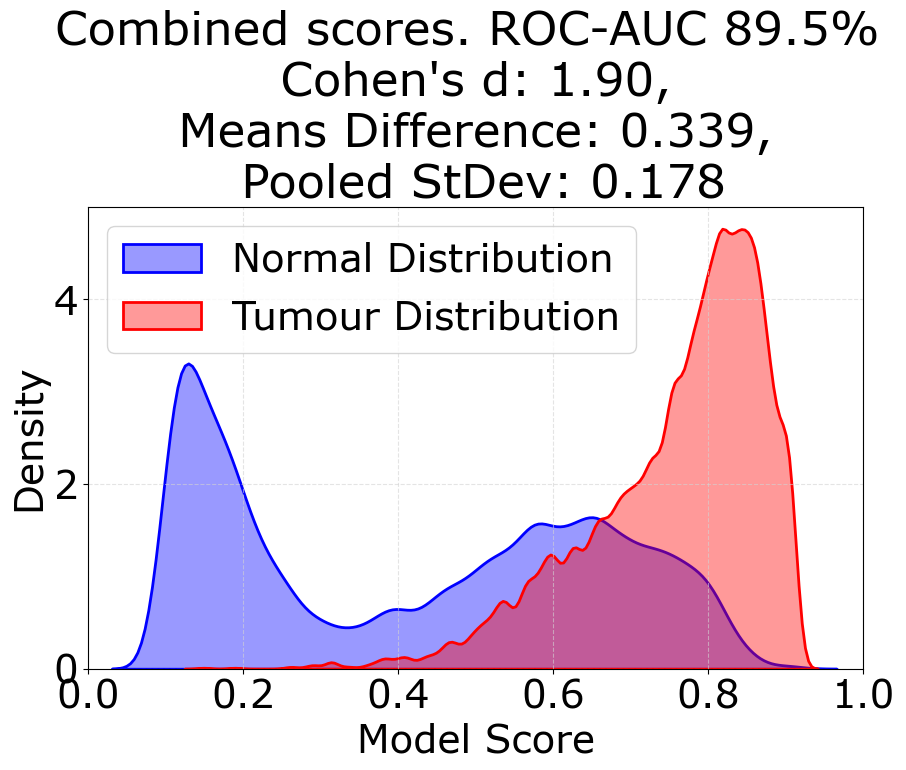

In [217]:
plot_filled_kde(
    result["combined_score"], result["label"], name="Combined scores. ROC-AUC 89.5% \n"
)

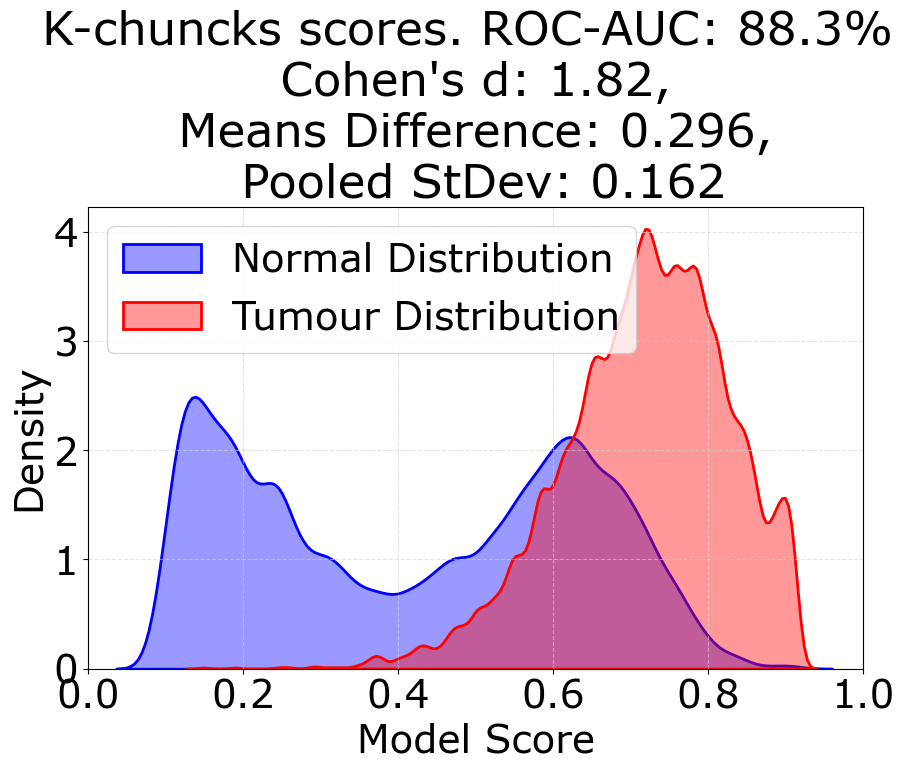

In [219]:
plot_filled_kde(
    predictions_proba_chunked,
    labels_chuncked,
    name="K-chuncks scores. ROC-AUC: 88.3% \n",
)

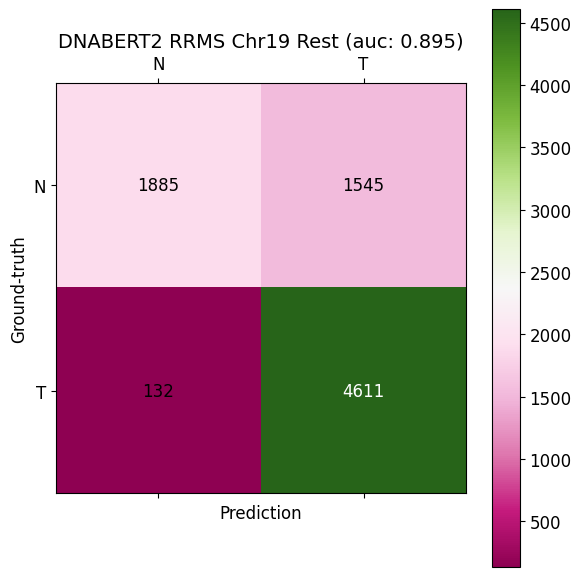

In [159]:
from sklearn.metrics import confusion_matrix, auc, roc_curve
import numpy as np

# Set Matplotlib styling
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "grid.color": "lightgray",
        "grid.linestyle": "-",
    }
)

# Compute confusion matrix
labels_filtered = np.array(result["label"])
predictions_filtered = np.array(result["combined_score"])

cf_matrix = confusion_matrix(labels_filtered, predictions_filtered > 0.5)

# Create the heatmap using Matplotlib
fig, ax = plt.subplots(1, figsize=(6, 6))
cax = ax.matshow(cf_matrix, cmap="PiYG")
plt.colorbar(cax)

# Annotate the heatmap
for (i, j), val in np.ndenumerate(cf_matrix):
    ax.text(
        j,
        i,
        f"{val}",
        ha="center",
        va="center",
        color="white" if val > cf_matrix.max() / 2 else "black",
    )

# Set axis labels and tick marks
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Ground-truth", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["N", "T"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["N", "T"])

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(labels_filtered, predictions_filtered)
auc_val = auc(fpr, tpr)

# Set title with AUC value
ax.set_title(f"DNABERT2 RRMS Chr19 Rest (auc: {auc_val:.3f})", fontsize=14)

# Show plot
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, auc, roc_curve
import numpy as np

# Set Matplotlib styling
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.facecolor": "white",
        "axes.edgecolor": "black",
        "grid.color": "lightgray",
        "grid.linestyle": "-",
    }
)

# Compute confusion matrix
labels_filtered = labels
predictions_filtered = np.array(predictions)

cf_matrix = confusion_matrix(labels_filtered, predictions_filtered > 0.5)

# Create the heatmap using Matplotlib
fig, ax = plt.subplots(1, figsize=(6, 6))
cax = ax.matshow(cf_matrix, cmap="PiYG")
plt.colorbar(cax)

# Annotate the heatmap
for (i, j), val in np.ndenumerate(cf_matrix):
    ax.text(
        j,
        i,
        f"{val}",
        ha="center",
        va="center",
        color="white" if val > cf_matrix.max() / 2 else "black",
    )

# Set axis labels and tick marks
ax.set_xlabel("Prediction", fontsize=12)
ax.set_ylabel("Ground-truth", fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(["N", "T"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["N", "T"])

# Compute ROC and AUC
fpr, tpr, thresholds = roc_curve(labels_filtered, predictions_filtered)
auc_val = auc(fpr, tpr)

# Set title with AUC value
ax.set_title(f"DNABERT2 RRMS Chr2 Rest (auc: {auc_val:.3f})", fontsize=14)

# Show plot
plt.tight_layout()
plt.show()

### Step 3: Predicting on Synthetic Data Without a Checkpoint

In this section, we'll initialize EpigenDnabert2 without loading a checkpoint. Instead, we'll create synthetic data with varying sequence lengths and optional features such as cpg_methylation and m6a_methylation. We'll then use the model to make predictions on this data.


In [ ]:
# Initialize EpigenDnabert2 without a checkpoint
epigenbert_no_checkpoint = EpigenDnabert2(
    fine_tuned_model_path=None, max_sequence_length=2**16, use_m6a_methylation=True
)

# Generate synthetic data
synthetic_data = generate_example_data(
    sequence_length=128,
    include_cpg_methylation=True,
    include_m6a_methylation=True,
    include_labels=False,
    num_samples=10,
)

# Create a dataset from the synthetic data
synthetic_dataset = SupervisedDataset(
    tokenizer=epigenbert_no_checkpoint.tokenizer,
    data_path_or_list=synthetic_data,
    kmer=-1,
)

# Make predictions on synthetic data
synthetic_predictions = epigenbert_no_checkpoint.predict(synthetic_dataset)